In [1]:
!pip install squarify


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
sys.path.append('..')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import mannwhitneyu, ttest_ind

import utilities.functions as functions

from utilities.graficos import plot_metricas
from utilities.graficos import (
  boxplot_meses
 
)


from utilities.functions import (
    gerar_stats,
    pedidos_group,
    criacao_ordens,
    conversao_imediata,
   
)

from utilities.testes_estatisticos import testes,teste_proporcao_por_janela
from utilities.outliers import(
    outlier_method,
    mark_outliers_iqr_zscore_mad
)

In [3]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df = pd.read_parquet(BASE_PATH / "gold" / "df_publico.parquet")

In [4]:
df=df[df['order_created_month']==12]#.head(1000)
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform,order_created_month,unique_order_hash,weekday,hour,day,total_amount_mes,ticket_medio,num_pedidos_mes,num_pedidos_hist,outlier_iqr,outlier_zscore,outlier_mad,lim_inf_iqr,lim_sup_iqr,zscore,mad_score,id_p99,id_p10
17,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,468f55386b6b45c114f292ba03ae6250012ef2aeda3cea...,2018-12-05 14:10:06+00:00,c773ed2e871b02f60a1812163b2953adb040b05e753808...,9.50,ANDROID,12,17691586763885382211,Wednesday,14,5,22.50,11.25,2,19,False,False,False,0.01,102.15,-1.06,-1.39,0,1
18,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2018-12-04 14:16:44+00:00,6a91dd04ba929af216ec1a8144e3992d552b281916cb9b...,13.00,ANDROID,12,3535338040383315140,Tuesday,14,4,22.50,11.25,2,19,False,False,False,0.01,102.15,-0.96,-1.23,0,1
24,b821aa8372b8e5b82cdc283742757df8c45eecdd72adf4...,control,True,2018-04-06T03:54:45.752Z,RJ,65b0d6b2fb8f46a7f5ff34e92a027ba16daede54050e8a...,2018-12-31 23:28:52+00:00,a182cc69e4a36e675eab25579595d51a48056aa304af78...,20.00,ANDROID,12,5222660554591170869,Monday,23,31,20.00,20.00,1,6,False,False,False,0.01,102.15,-0.14,-0.91,0,0
45,d425d6ee4c9d4e211b71da8fc60bf6c5336b2ea9af9cc0...,control,True,2018-01-06T21:04:49.159Z,SP,2f1f388732fe98108ab117e89954ebf8fcb8abee50e116...,2018-12-12 22:15:22+00:00,a31ea26614781a1efca03a9cda135f4abf79d7c6e5b2e9...,45.00,IOS,12,16377365159234429210,Wednesday,22,12,703.70,63.97,11,31,False,False,False,0.01,102.15,-0.01,0.24,0,0
46,d425d6ee4c9d4e211b71da8fc60bf6c5336b2ea9af9cc0...,control,True,2018-01-06T21:04:49.159Z,SP,12e7a61b43666ef30af2440923b2945f6e694a3b85d27c...,2018-12-10 21:24:56+00:00,9341f4389b614cb02194d624312ec385cdde0fcd0634b0...,70.00,DESKTOP,12,3044180806641378589,Monday,21,10,703.70,63.97,11,31,False,False,False,0.01,102.15,0.11,1.39,0,0


In [5]:
outlier_method(df,var='order_total_amount')

Use MAD (assimétrico + robusto)


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1234460.
  res = hypotest_fun_out(*samples, **kwds)


'mad'

In [6]:
df = mark_outliers_iqr_zscore_mad(df)


In [7]:
df_outliers = df[
   # df['outlier_iqr'] & 
   # df['outlier_zscore'] & 
    df['outlier_mad']]
print(len(df_outliers))
df_outliers.describe()

49303


,order_total_amount,order_created_month,unique_order_hash,hour,day,total_amount_mes,ticket_medio,num_pedidos_mes,num_pedidos_hist,lim_inf_iqr,lim_sup_iqr,zscore,mad_score,id_p99,id_p10
count,"49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00","49,303.00"
mean,167.64,12.00,"9,185,286,726,571,500,544.00",16.71,17.81,512.54,131.40,4.52,12.29,0.01,102.15,2.17,5.87,0.41,0.06
std,630.53,0.00,"5,322,074,512,250,202,112.00",7.79,8.21,"1,019.89",453.11,4.39,12.30,0.00,0.00,3.84,28.93,0.49,0.23
min,116.09,12.00,"895,929,496,434,305.00",0.00,3.00,116.09,25.68,1.00,2.00,0.01,102.15,0.35,3.50,0.00,0.00
25%,127.70,12.00,"4,559,743,737,504,591,872.00",15.00,11.00,199.00,90.60,2.00,4.00,0.01,102.15,0.54,4.03,0.00,0.00
50%,144.50,12.00,"9,185,815,041,828,856,832.00",21.00,17.00,346.00,119.00,3.00,8.00,0.01,102.15,2.07,4.80,0.00,0.00
75%,176.00,12.00,"13,808,068,390,135,396,352.00",22.00,24.00,623.30,147.35,6.00,16.00,0.01,102.15,2.87,6.25,1.00,0.00
max,"138,750.90",12.00,"18,446,323,495,608,420,352.00",23.00,31.00,"140,338.90","70,169.45",82.00,239.00,0.01,102.15,704.08,"6,364.67",1.00,1.00


In [8]:
df=df[~df['customer_id'].isin(df_outliers['customer_id'].unique())]

In [9]:
df['outlier_mad'].unique()

array([False])

In [10]:
data_maxima = df['order_created_at'].max()


In [11]:
#df=df[df['customer_id']!='361e229dbc1b985e1aacb3e70384782a05d77ad6db53e7e511fe2147ee09a890']

In [12]:
rfm = df.groupby(['customer_id','is_target']).agg({
    'order_created_at': lambda x: (data_maxima - x.max()).days,  
    'unique_order_hash': 'count',  
    'order_total_amount': 'sum'  
}).reset_index()

In [13]:
rfm.head()

,customer_id,is_target,order_created_at,unique_order_hash,order_total_amount
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,11,2,100.00
1,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,2,119.90
2,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,1,2,68.65
3,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,16,1,88.80
4,0000bb10fb47a1d6b2d73754ef383950ef536c77d07212...,control,10,2,188.19


In [14]:

rfm.columns = ['customer_id','is_target', 'recencia', 'frequencia', 'valor_monetario']

rfm.head()

,customer_id,is_target,recencia,frequencia,valor_monetario
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,11,2,100.00
1,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,2,119.90
2,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,1,2,68.65
3,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,16,1,88.80
4,0000bb10fb47a1d6b2d73754ef383950ef536c77d07212...,control,10,2,188.19


In [15]:
rfm.shape

(518228, 5)

In [16]:

for col, inv in [('recencia', True), ('frequencia', False), ('valor_monetario', False)]:
    rank = rfm[col].rank(method='first')
    if inv:
        rfm[f'{col[0]}_score'] = pd.qcut(rank, q=4, labels=[4,3,2,1])
    else:
        rfm[f'{col[0]}_score'] = pd.qcut(rank, q=4, labels=[1,2,3,4])

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['v_score'].astype(str)



In [17]:
rfm.reset_index().sort_values(by=['f_score'], ascending=[False]).head()


,index,customer_id,is_target,recencia,frequencia,valor_monetario,r_score,f_score,v_score,rfm_score
107872,107872,354f4f9c86422a5fda14a4d89acab9dbec8824911d92b0...,control,1,5,245.20,4,4,4,444
128861,128861,3fa8f050571fb2a6b59181305ab7b7df1b021c938ef886...,control,0,6,248.50,4,4,4,444
364438,364438,b4325a6673d46c4fdff3ca3562c316fe577978629ece19...,target,10,3,77.40,2,4,3,243
364435,364435,b431ef45564ca1cdad312e884b8b7fbae1d0feeec271fd...,target,3,3,129.30,3,4,4,344
128869,128869,3fa9d16338ee1600b0f51144b23e053c03132b6b9affb8...,target,1,3,88.18,4,4,3,443


In [18]:
df_stats_mes = (
        rfm.groupby(['rfm_score','is_target'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              media=("valor_monetario", 'mean'))) .reset_index().sort_values(by=['media'], ascending=[False])

df_stats_mes.head()

,rfm_score,is_target,total_clientes,media
127,444,target,28858,253.24
126,444,control,19145,252.99
94,344,control,13698,212.06
95,344,target,19923,211.68
62,244,control,6123,183.28


In [19]:
rfm_avg = rfm.pivot_table(
    index='r_score', 
    columns='f_score', 
    values='valor_monetario', 
    aggfunc='mean'
)


/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_5066/1539231617.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rfm_avg = rfm.pivot_table(


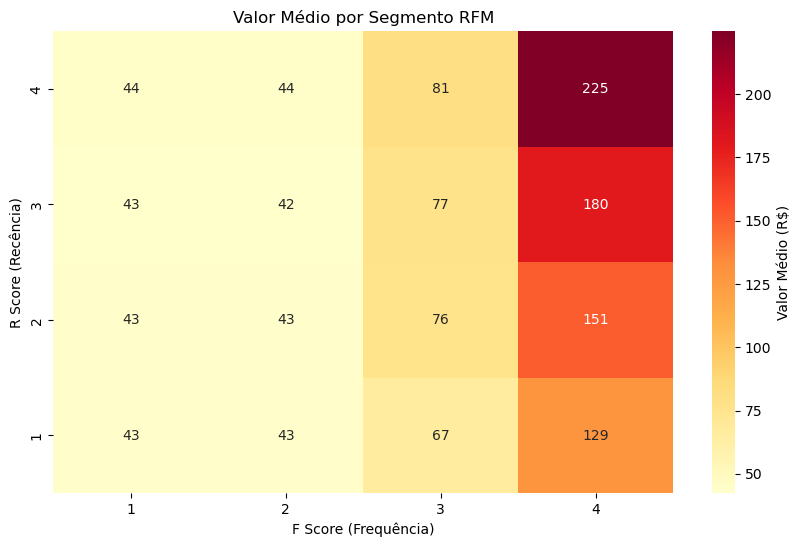

In [20]:
# Média do Valor Monetário por célula RFM

plt.figure(figsize=(10, 6))
sns.heatmap(rfm_avg, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Valor Médio (R$)'})
plt.title('Valor Médio por Segmento RFM')
plt.xlabel('F Score (Frequência)')
plt.ylabel('R Score (Recência)')
plt.show()


In [21]:

rfm_treemap = rfm_avg.reset_index().melt(
    id_vars='r_score',
    var_name='f_score',
    value_name='valor_medio'
)

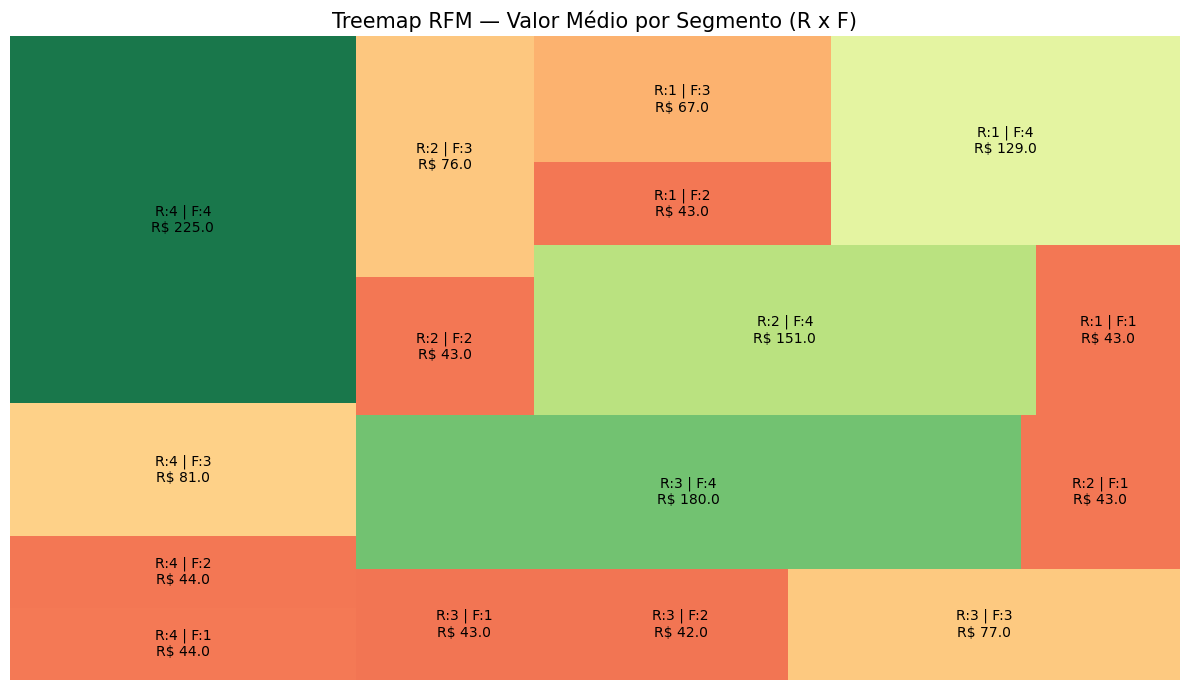

In [22]:
rfm_treemap = rfm_avg.reset_index().melt(
    id_vars='r_score',
    var_name='f_score',
    value_name='valor_medio'
)

# 2) Ordenar por R e depois por F
rfm_treemap = rfm_treemap.sort_values(['r_score', 'f_score']).reset_index(drop=True)

# 3) Criar rótulos
rfm_treemap["label"] = (
    "R:" + rfm_treemap["r_score"].astype(str) +
    " | F:" + rfm_treemap["f_score"].astype(str) +
    "\nR$ " + rfm_treemap["valor_medio"].round(0).astype(str)
)

# 4) Normalizar valores para o colormap
norm_vals = rfm_treemap["valor_medio"] / rfm_treemap["valor_medio"].max()
colors = plt.cm.RdYlGn(norm_vals)   # verde = alto valor, vermelho = baixo


# 5) Plot do Treemap
plt.figure(figsize=(12, 7))

squarify.plot(
    sizes=rfm_treemap["valor_medio"],
    label=rfm_treemap["label"],
    color=colors,
    alpha=0.9,
    text_kwargs={'fontsize': 10, 'color': 'black'}
)

plt.title("Treemap RFM — Valor Médio por Segmento (R x F)", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()

In [26]:
seg_map = (
    rfm_avg
    .reset_index()
    .melt(id_vars='r_score', var_name='f_score', value_name='media_valor')
)

# 2) rotula cada média como "media X"
seg_map['segmento'] = 'media ' + seg_map['media_valor'].round(0).astype(int).astype(str)

# 3) agrupa 46, 47 e 48 num único grupo
seg_map.loc[seg_map['media_valor'].round().isin([43, 44, 42]), 'segmento'] = 'media 42-44'

# 4) aplica no dataframe original
rfm_segmentado = rfm.merge(
    seg_map[['r_score', 'f_score', 'segmento']],
    on=['r_score', 'f_score'],
    how='left'
)

In [27]:
rfm_segmentado.head()

,customer_id,is_target,recencia,frequencia,valor_monetario,r_score,f_score,v_score,rfm_score,segmento
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,11,2,100.00,2,3,3,233,media 76
1,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,2,119.90,4,3,4,434,media 81
2,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,1,2,68.65,4,3,3,433,media 81
3,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,16,1,88.80,2,1,3,213,media 42-44
4,0000bb10fb47a1d6b2d73754ef383950ef536c77d07212...,control,10,2,188.19,2,3,4,234,media 76


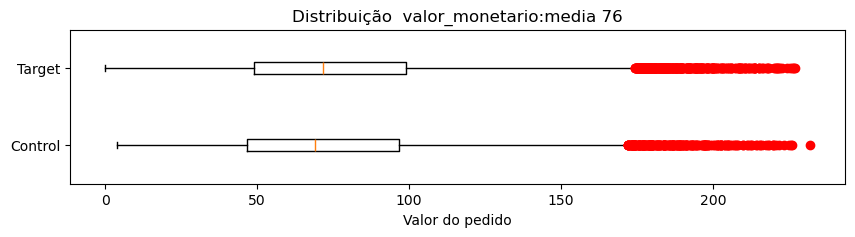

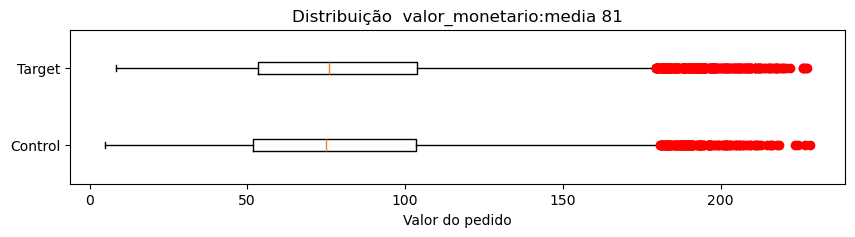

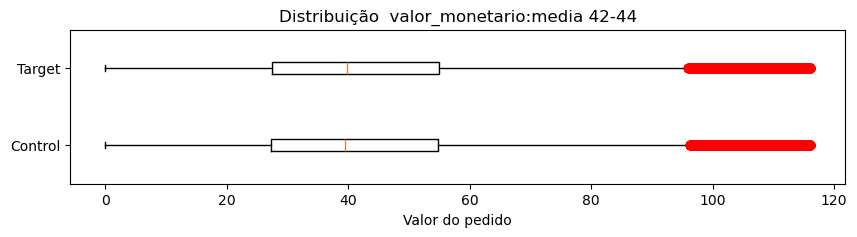

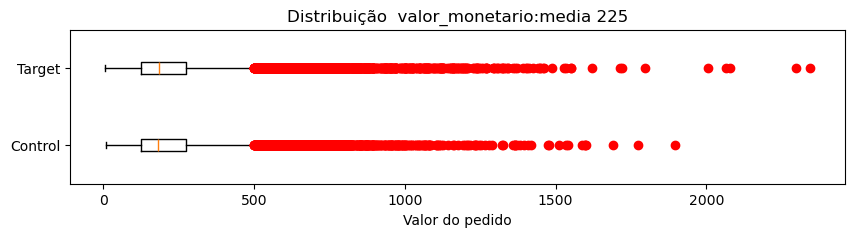

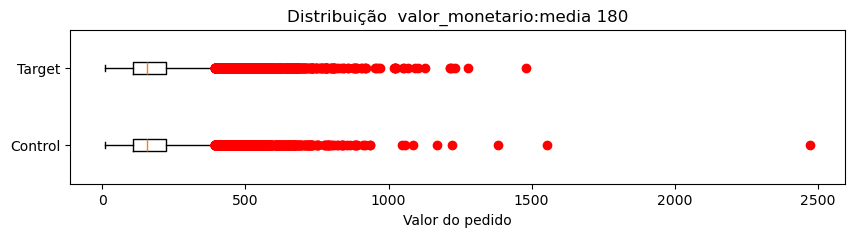

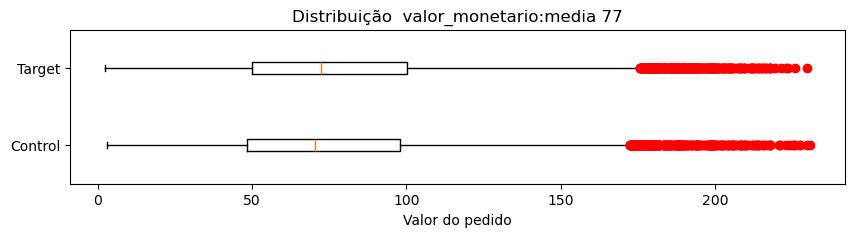

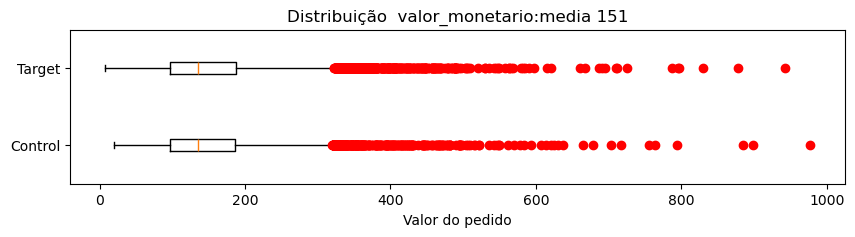

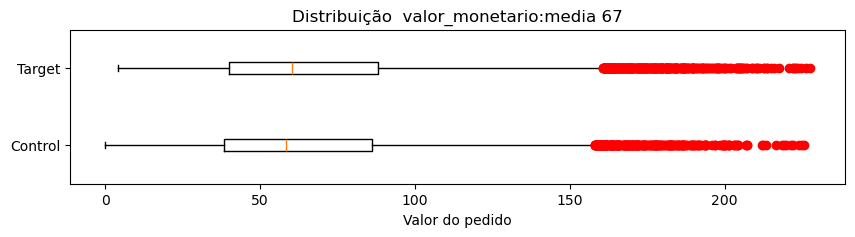

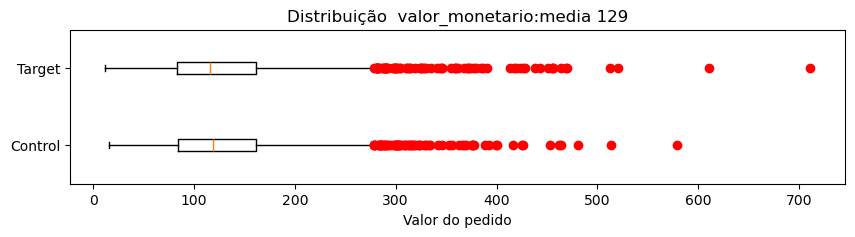

In [28]:
boxplot_meses(rfm_segmentado,var_cat='segmento',var_cont='valor_monetario')